In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [22]:
ticker = "SPY"

data = yf.download(ticker, start="2015-01-01", end="2024-12-31")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687836,170.885565,168.655319,170.472558,121465900
2015-01-05,166.623276,168.812204,166.317655,168.647004,169632600
2015-01-06,165.053909,167.449342,164.260931,166.928950,209151400
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700
2015-01-08,170.076019,170.290791,168.498345,168.514856,147217800


In [23]:
close_price = data["Close"]

close_price.head()

Ticker,SPY
Date,
2015-01-02,169.687836
2015-01-05,166.623276
2015-01-06,165.053909
2015-01-07,167.110687
2015-01-08,170.076019


In [24]:
returns = close_price.pct_change().dropna()

returns.head()

Ticker,SPY
Date,
2015-01-05,-0.018060
2015-01-06,-0.009419
2015-01-07,0.012461
2015-01-08,0.017745
2015-01-09,-0.008013


In [25]:
data["SMA_50"] = close_price.rolling(window=50).mean()
data["SMA_200"] = close_price.rolling(window=200).mean()

data[["Close", "SMA_50", "SMA_200"]].tail()

Price,Close,SMA_50,SMA_200
Ticker,SPY,,
Date,,,
2024-12-23,584.680420,579.814412,538.935990
2024-12-24,591.179199,580.186840,539.410346
2024-12-26,591.218506,580.649026,539.858203
2024-12-27,584.994934,580.937352,540.278875
2024-12-30,578.319275,581.091188,540.671118


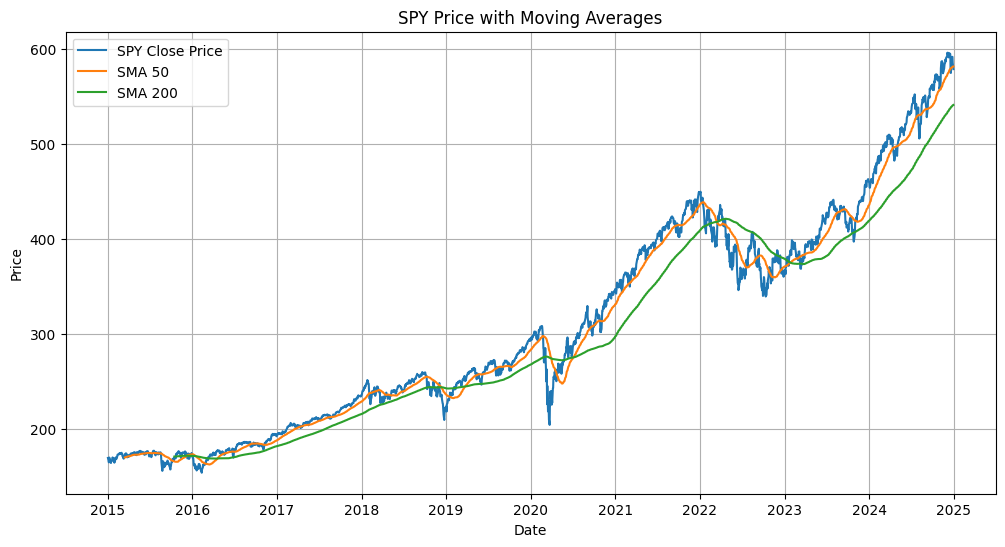

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="SPY Close Price")
plt.plot(data["SMA_50"], label="SMA 50")
plt.plot(data["SMA_200"], label="SMA 200")

plt.title("SPY Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
data["Signal"] = 0

data.loc[data["SMA_50"] > data["SMA_200"], "Signal"] = 1

data[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Ticker,SPY,,,
Date,,,,
2024-12-23,584.680420,579.814412,538.935990,1
2024-12-24,591.179199,580.186840,539.410346,1
2024-12-26,591.218506,580.649026,539.858203,1
2024-12-27,584.994934,580.937352,540.278875,1
2024-12-30,578.319275,581.091188,540.671118,1


In [28]:
data["Position"] = data["Signal"].shift(1)

data[["Signal", "Position"]].tail()

Price,Signal,Position
Ticker,,
Date,,
2024-12-23,1,1.0
2024-12-24,1,1.0
2024-12-26,1,1.0
2024-12-27,1,1.0
2024-12-30,1,1.0


In [29]:
data["Buy_Hold_Returns"] = close_price.pct_change()

data["Strategy_Returns"] = data["Position"] * data["Buy_Hold_Returns"]

data[["Buy_Hold_Returns", "Strategy_Returns"]].dropna().head()

Price,Buy_Hold_Returns,Strategy_Returns
Ticker,,
Date,,
2015-01-05,-0.018060,-0.0
2015-01-06,-0.009419,-0.0
2015-01-07,0.012461,0.0
2015-01-08,0.017745,0.0
2015-01-09,-0.008013,-0.0


In [30]:
data["Buy_Hold_Cumulative"] = (1 + data["Buy_Hold_Returns"]).cumprod()

data["Strategy_Cumulative"] = (1 + data["Strategy_Returns"]).cumprod()

data[["Buy_Hold_Cumulative", "Strategy_Cumulative"]].tail()

Price,Buy_Hold_Cumulative,Strategy_Cumulative
Ticker,,
Date,,
2024-12-23,3.445624,2.420964
2024-12-24,3.483922,2.447874
2024-12-26,3.484154,2.448036
2024-12-27,3.447477,2.422267
2024-12-30,3.408136,2.394625


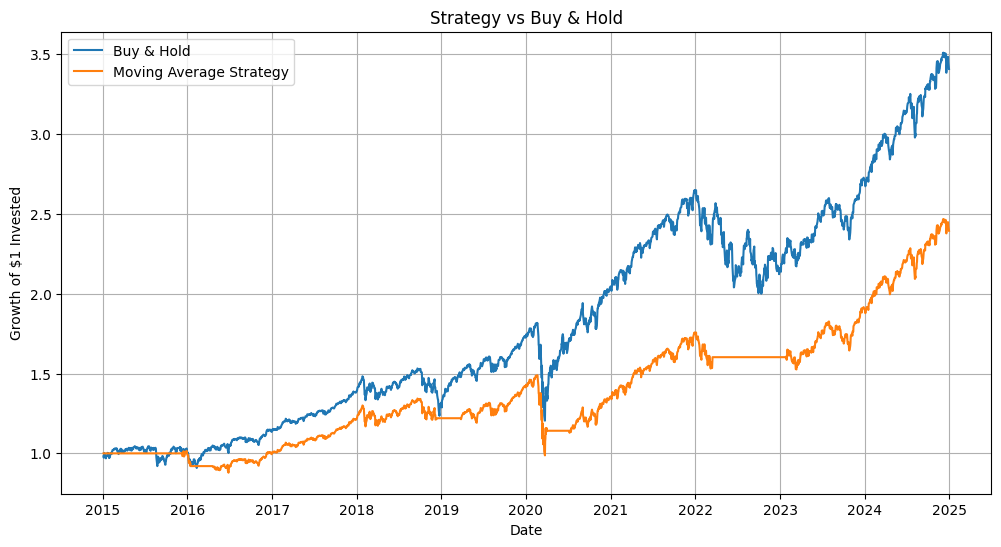

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(data["Buy_Hold_Cumulative"], label="Buy & Hold")
plt.plot(data["Strategy_Cumulative"], label="Moving Average Strategy")

plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
strategy_returns = data["Strategy_Returns"].dropna()
buy_hold_returns = data["Buy_Hold_Returns"].dropna()

strategy_annual_return = strategy_returns.mean() * 252
strategy_annual_volatility = strategy_returns.std() * np.sqrt(252)
strategy_sharpe_ratio = strategy_annual_return / strategy_annual_volatility

buy_hold_annual_return = buy_hold_returns.mean() * 252
buy_hold_annual_volatility = buy_hold_returns.std() * np.sqrt(252)
buy_hold_sharpe_ratio = buy_hold_annual_return / buy_hold_annual_volatility

print("Strategy Annual Return:", strategy_annual_return)
print("Strategy Annual Volatility:", strategy_annual_volatility)
print("Strategy Sharpe Ratio:", strategy_sharpe_ratio)

print("Buy & Hold Annual Return:", buy_hold_annual_return)
print("Buy & Hold Annual Volatility:", buy_hold_annual_volatility)
print("Buy & Hold Sharpe Ratio:", buy_hold_sharpe_ratio)

Strategy Annual Return: 0.09749269598281982
Strategy Annual Volatility: 0.1405761376990022
Strategy Sharpe Ratio: 0.6935223685798547
Buy & Hold Annual Return: 0.13853010988666312
Buy & Hold Annual Volatility: 0.1762219292857889
Buy & Hold Sharpe Ratio: 0.7861116402942175


In [33]:
strategy_running_max = data["Strategy_Cumulative"].cummax()

strategy_drawdown = (data["Strategy_Cumulative"] / strategy_running_max) - 1

strategy_drawdown.tail()

Date
2024-12-23   -0.018293
2024-12-24   -0.007381
2024-12-26   -0.007315
2024-12-27   -0.017764
2024-12-30   -0.028973
Name: Strategy_Cumulative, dtype: float64

In [34]:
strategy_max_drawdown = strategy_drawdown.min()

strategy_max_drawdown

np.float64(-0.3371724789931766)

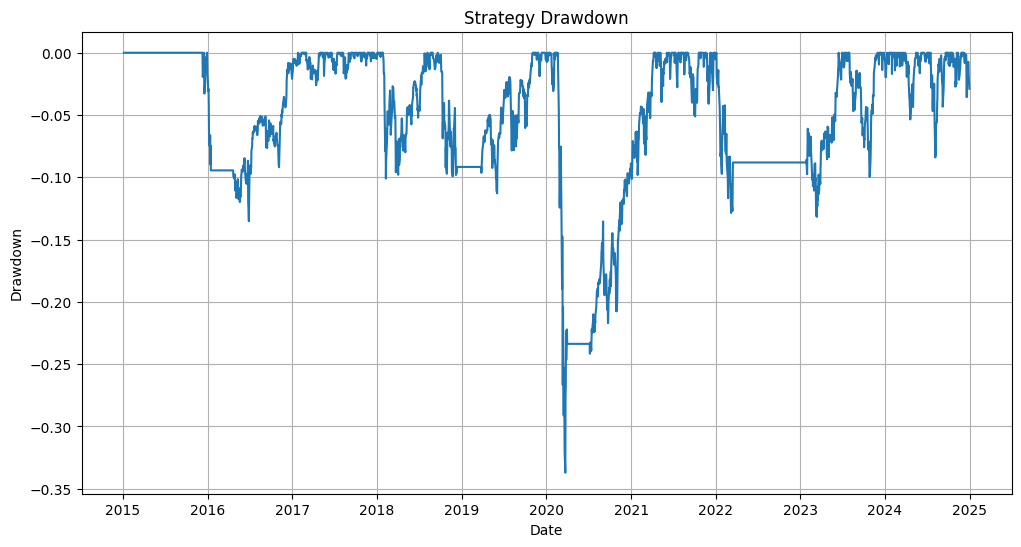

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(strategy_drawdown)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)

plt.show()

In [36]:
strategy_summary = pd.DataFrame({
    "Metric": [
        "Strategy Annual Return",
        "Strategy Annual Volatility",
        "Strategy Sharpe Ratio",
        "Strategy Maximum Drawdown",
        "Buy & Hold Annual Return",
        "Buy & Hold Annual Volatility",
        "Buy & Hold Sharpe Ratio"
    ],
    "Value": [
        strategy_annual_return,
        strategy_annual_volatility,
        strategy_sharpe_ratio,
        strategy_max_drawdown,
        buy_hold_annual_return,
        buy_hold_annual_volatility,
        buy_hold_sharpe_ratio
    ]
})

strategy_summary

,Metric,Value
0,Strategy Annual Return,0.097493
1,Strategy Annual Volatility,0.140576
2,Strategy Sharpe Ratio,0.693522
3,Strategy Maximum Drawdown,-0.337172
4,Buy & Hold Annual Return,0.138530
5,Buy & Hold Annual Volatility,0.176222
6,Buy & Hold Sharpe Ratio,0.786112


In [37]:
strategy_summary.to_csv("../data/strategy_summary.csv", index=False)

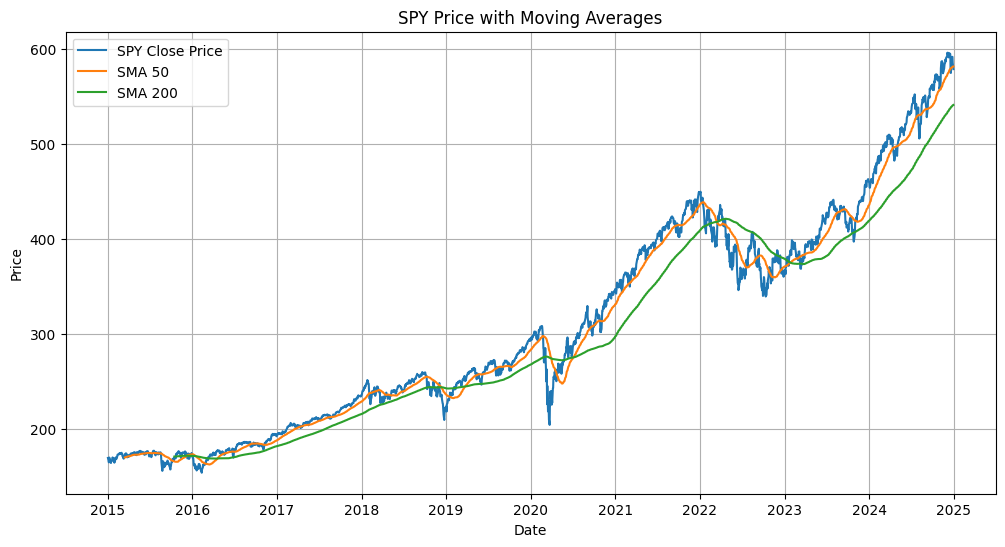

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="SPY Close Price")
plt.plot(data["SMA_50"], label="SMA 50")
plt.plot(data["SMA_200"], label="SMA 200")

plt.title("SPY Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.savefig("../images/moving_average_signals.png", bbox_inches="tight")

plt.show()

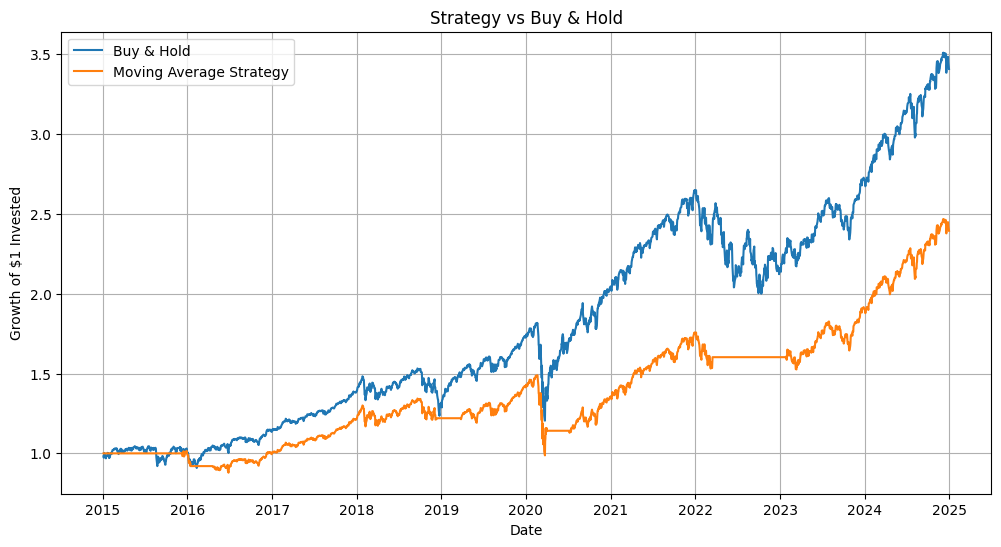

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(data["Buy_Hold_Cumulative"], label="Buy & Hold")
plt.plot(data["Strategy_Cumulative"], label="Moving Average Strategy")

plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True)

plt.savefig("../images/strategy_vs_buy_hold.png", bbox_inches="tight")

plt.show()

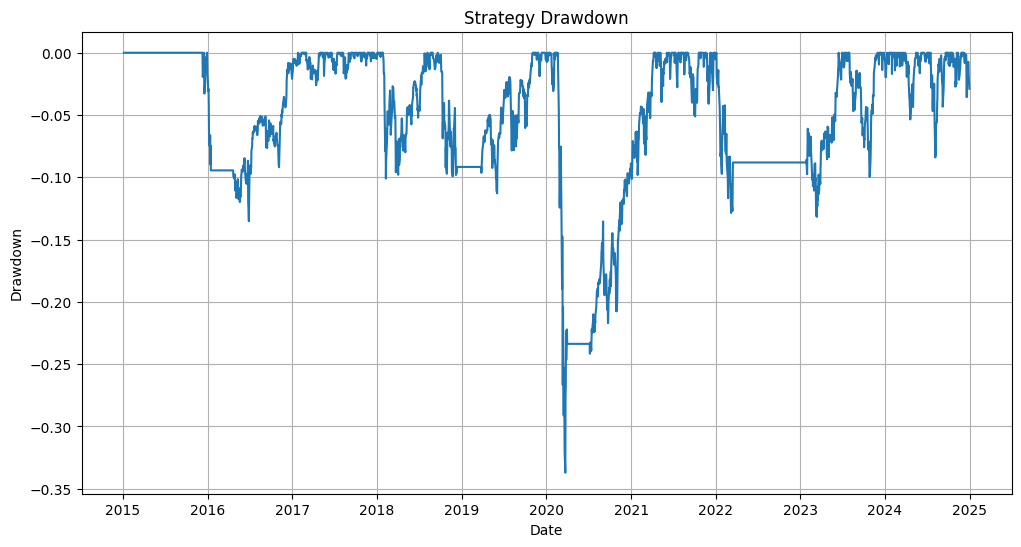

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(strategy_drawdown)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)

plt.savefig("../images/strategy_drawdown.png", bbox_inches="tight")

plt.show()